# Informe Final - RandomForest para Offer_Received
- **Juan Diego Grajales Castillo - 20221020128**
- **Julian David Celis Giraldo - 20222020041**
- **David Santiago Aldana Gonzalez - 20222020158**
- **Sara Nicolle Martinez Moreno - 20231020116**

## Objetivo General

Queremos construir un sistema que **prediga si un estudiante recibira una oferta de trabajo** en funcion de sus caracteristicas (GPA, numero de entrevistas, aplicaciones, etc.).

Este notebook entrena un **modelo de prediccion** (RandomForestClassifier) que aprende reglas no lineales para clasificar estudiantes en dos categorias:
- **Categoria 0**: "Probablemente NO reciba oferta"
- **Categoria 1**: "Probablemente SI reciba oferta"

## Que es Random Forest?

Es un modelo de ensamble que combina muchos arboles de decision:
1. Cada arbol aprende patrones del dataset.
2. Cada arbol vota una clase (oferta / sin oferta).
3. El bosque decide la clase final por votacion agregada.

## Reportaremos
- Matriz de confusion
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC


## Bloque 0: Configuracion reproducible y control metodologico

### Funcion del bloque
Establecer un entorno replicable para que los resultados del modelo sean auditables y comparables entre ejecuciones.

### Decision metodologica (por que esta opcion)
Se fija una semilla global (`SEED=42`) y se centralizan imports para evitar variaciones aleatorias no controladas.

### Por que no otra alternativa
No usar semilla puede cambiar el split y el ajuste del bosque entre corridas, dificultando la comparacion tecnica.

### Como se implementa
1. Se importan librerias de manipulación, visualizacion y modelado.
2. Se define `SEED` y se propaga con `np.random.seed(SEED)`.
3. Se configura un estilo grafico uniforme.


In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
)

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid')

## Bloque 1: Carga y diagnostico estructural del dataset

### Funcion del bloque
Validar que el dataset candidato a entrenamiento tenga integridad basica antes de construir el pipeline.

### Decision metodologica (por que esta opcion)
Se ejecuta un diagnostico temprano de estructura (filas, columnas, tipos, nulos y distribucion objetivo) para detectar problemas que sesgan entrenamiento y evaluacion.

### Como se implementa
1. Se carga `dataset_offer_Received.csv`.
2. Se generan tablas de control: resumen general, catalogo de variables y distribucion de clase.
3. Se valida la existencia de la variable objetivo `Offer_Received`.


In [7]:
PROJECT_ROOT = Path('.').resolve()
DATA_PATH = PROJECT_ROOT / 'cleanData' / 'dataset_offer_Received.csv'
TARGET = 'Offer_Received'

df = pd.read_csv(DATA_PATH)

dataset_overview_df = pd.DataFrame([
    {'Indicador': 'Archivo', 'Valor': DATA_PATH.name},
    {'Indicador': 'Filas', 'Valor': f"{df.shape[0]:,}"},
    {'Indicador': 'Columnas', 'Valor': df.shape[1]},
    {'Indicador': 'Nulos totales', 'Valor': int(df.isna().sum().sum())},
])

feature_catalog_df = pd.DataFrame({
    'Variable': df.columns,
    'Tipo': [str(df[c].dtype) for c in df.columns],
})

target_distribution_df = (
    df[TARGET]
    .value_counts(dropna=False)
    .rename_axis('Clase')
    .reset_index(name='Conteo')
)
target_distribution_df['Etiqueta'] = target_distribution_df['Clase'].map({1: 'SI OFERTA', 0: 'NO OFERTA'})
target_distribution_df['Porcentaje'] = (target_distribution_df['Conteo'] / len(df)).round(4)

display(dataset_overview_df)
display(feature_catalog_df)
display(target_distribution_df[['Clase', 'Etiqueta', 'Conteo', 'Porcentaje']])

,Indicador,Valor
0,Archivo,dataset_offer_Received.csv
1,Filas,"100,000"
2,Columnas,14
3,Nulos totales,0


,Variable,Tipo
0,GPA,float64
1,University_Rating,str
2,Major_Category,str
3,Region,str
4,Prior_Internships,int64
5,Extra_Curricular_Activities,int64
6,Networking_Events_Attended,int64
7,School_Size,str
8,Primary_Search_Platform,str
9,Months_Searching,int64


,Clase,Etiqueta,Conteo,Porcentaje
0,0,NO OFERTA,65771,0.6577
1,1,SI OFERTA,34229,0.3423


## Bloque 2: Preparacion de variables y particion estratificada

### Funcion del bloque
Separar predictor/target y construir particiones de entrenamiento/prueba representativas.

### Decision metodologica (por que esta opcion)
Se usa `train_test_split` estratificado para conservar la proporcion de clases entre train y test.

### Como se implementa
1. Se define `X` con features y `y` con `Offer_Received`.
2. Se separan variables numericas y categoricas para preprocesamiento diferencial.
3. Se construye split 80/20 con `stratify=y` y `random_state=SEED`.


In [8]:
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

categorical_cols = X.select_dtypes(include=['object', 'category', 'string', 'str']).columns.tolist()
numeric_cols = X.select_dtypes(include=['number']).columns.tolist()

feature_groups_df = pd.DataFrame({
    'Tipo de variable': ['Numerica', 'Categorica'],
    'Cantidad': [len(numeric_cols), len(categorical_cols)],
    'Variables': [', '.join(numeric_cols), ', '.join(categorical_cols)],
})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

split_summary_df = pd.DataFrame([
    {
        'Conjunto': 'Train',
        'Filas': X_train.shape[0],
        'Proporcion_sobre_total': round(X_train.shape[0] / X.shape[0], 4),
        'Tasa_SI_OFERTA': round(y_train.mean(), 4),
    },
    {
        'Conjunto': 'Test',
        'Filas': X_test.shape[0],
        'Proporcion_sobre_total': round(X_test.shape[0] / X.shape[0], 4),
        'Tasa_SI_OFERTA': round(y_test.mean(), 4),
    },
])

display(feature_groups_df)
display(split_summary_df)

,Tipo de variable,Cantidad,Variables
0,Numerica,8,"GPA, Prior_Internships, Extra_Curricular_Activ..."
1,Categorica,5,"University_Rating, Major_Category, Region, Sch..."


,Conjunto,Filas,Proporcion_sobre_total,Tasa_SI_OFERTA
0,Train,80000,0.8,0.3423
1,Test,20000,0.2,0.3423


## Bloque 3: Entrenamiento y evaluacion del modelo (Random Forest puro)

### Funcion del bloque
Entrenar un Random Forest base y evaluar su desempeno en datos no vistos.

### Decision metodologica (por que esta opcion)
En esta iteracion se entrena un **RandomForestClassifier sin tuning** para establecer una linea base clara del algoritmo.

### Por que no otra alternativa
No se usa GridSearch/RandomizedSearch ni ajuste de umbral en esta fase para mantener el experimento puro y facil de auditar.

### Como se implementa
1. Pipeline con `ColumnTransformer`: OneHotEncoder para categoricas y passthrough para numericas.
2. Entrenamiento de Random Forest con semilla fija.
3. Evaluacion en test con matriz de confusion y metricas estandar.


,Metrica,Valor
0,Accuracy,0.9062
1,Precision,0.8302
2,Recall,0.9126
3,F1-Score,0.8695
4,ROC-AUC,0.9670


Reporte de clasificacion:
              precision    recall  f1-score   support

           0     0.9521    0.9028    0.9268     13154
           1     0.8302    0.9126    0.8695      6846

    accuracy                         0.9062     20000
   macro avg     0.8911    0.9077    0.8981     20000
weighted avg     0.9103    0.9062    0.9072     20000



,Pred: SI OFERTA (1),Pred: NO OFERTA (0)
Real: SI OFERTA (1),6248,598
Real: NO OFERTA (0),1278,11876


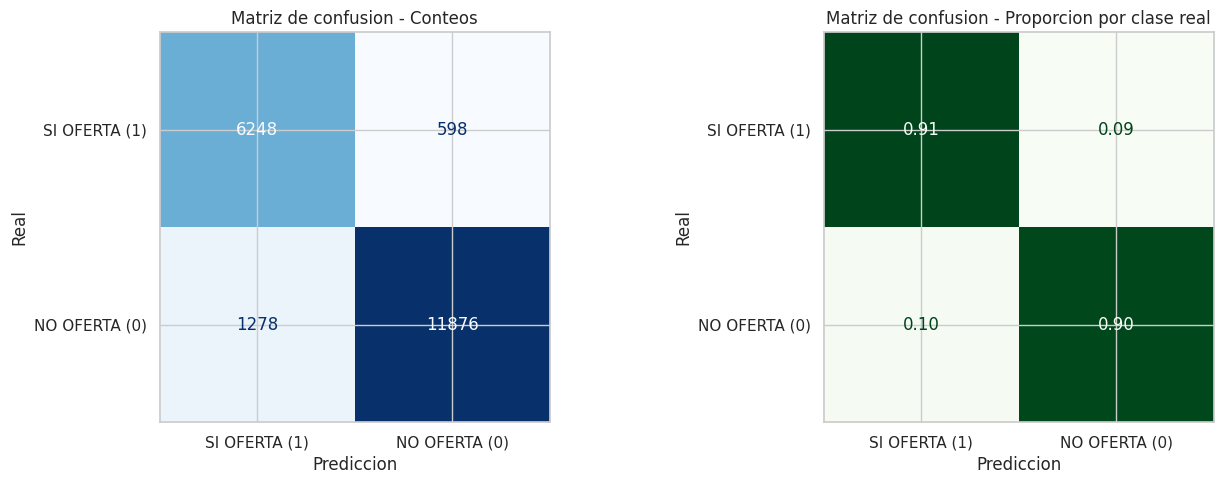

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ],
    remainder='passthrough',
)

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=SEED, n_jobs=-1)),
])

rf_pipeline.fit(X_train, y_train)

y_test_proba = rf_pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_test_proba >= 0.50).astype(int)

metrics_df = pd.DataFrame([
    {'Metrica': 'Accuracy', 'Valor': accuracy_score(y_test, y_pred)},
    {'Metrica': 'Precision', 'Valor': precision_score(y_test, y_pred, zero_division=0)},
    {'Metrica': 'Recall', 'Valor': recall_score(y_test, y_pred, zero_division=0)},
    {'Metrica': 'F1-Score', 'Valor': f1_score(y_test, y_pred, zero_division=0)},
    {'Metrica': 'ROC-AUC', 'Valor': roc_auc_score(y_test, y_test_proba)},
])
metrics_df['Valor'] = metrics_df['Valor'].round(4)
display(metrics_df)

print('Reporte de clasificacion:')
print(classification_report(y_test, y_pred, digits=4))

labels_order = [1, 0]
label_names = ['SI OFERTA (1)', 'NO OFERTA (0)']
cm = confusion_matrix(y_test, y_pred, labels=labels_order)

cm_df = pd.DataFrame(
    cm,
    index=['Real: SI OFERTA (1)', 'Real: NO OFERTA (0)'],
    columns=['Pred: SI OFERTA (1)', 'Pred: NO OFERTA (0)'],
)
display(cm_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp_abs = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp_abs.plot(cmap='Blues', ax=axes[0], colorbar=False, values_format='d')
axes[0].set_title('Matriz de confusion - Conteos')
axes[0].set_xlabel('Prediccion')
axes[0].set_ylabel('Real')

cm_norm = cm / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=label_names)
disp_norm.plot(cmap='Greens', ax=axes[1], colorbar=False, values_format='.2f')
axes[1].set_title('Matriz de confusion - Proporcion por clase real')
axes[1].set_xlabel('Prediccion')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

## Bloque 4: Importancia de variables del modelo

### Funcion del bloque
Identificar que variables estan aportando mas a la decision del bosque.

### Decision metodologica (por que esta opcion)
En Random Forest se usa `feature_importances_` para estimar la contribucion relativa de cada feature transformada.

### Como se implementa
1. Se obtienen nombres de features transformadas del preprocesador.
2. Se extraen importancias del bosque ajustado.
3. Se agrega importancia por variable original y se grafica el top 10.


,feature_transformed,importance,base_variable
0,remainder__First_Round_Interviews,0.286670,First_Round_Interviews
1,remainder__Second_Round_Interviews,0.285986,Second_Round_Interviews
2,remainder__Applications_Submitted,0.091307,Applications_Submitted
3,remainder__GPA,0.064500,GPA
4,remainder__Months_Searching,0.041823,Months_Searching
5,remainder__Prior_Internships,0.041319,Prior_Internships
6,remainder__Networking_Events_Attended,0.033089,Networking_Events_Attended
7,remainder__Extra_Curricular_Activities,0.029517,Extra_Curricular_Activities
8,cat__Primary_Search_Platform_Indeed,0.012055,Primary_Search_Platform
9,cat__Primary_Search_Platform_Handshake,0.010513,Primary_Search_Platform


,base_variable,importance
0,First_Round_Interviews,0.286670
1,Second_Round_Interviews,0.285986
2,Applications_Submitted,0.091307
3,GPA,0.064500
4,Months_Searching,0.041823
5,Prior_Internships,0.041319
6,Networking_Events_Attended,0.033089
7,Primary_Search_Platform,0.030367
8,Extra_Curricular_Activities,0.029517
9,Region,0.028924


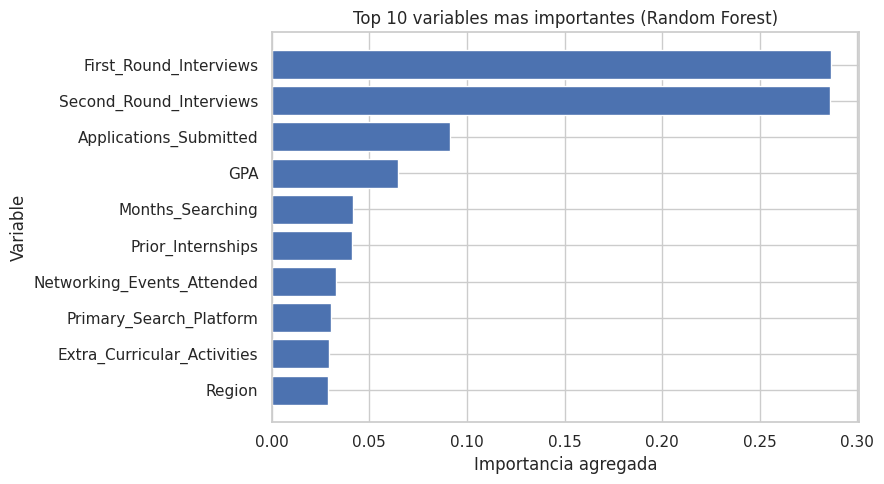

In [10]:
preprocessor_fitted = rf_pipeline.named_steps['preprocessor']
rf_fitted = rf_pipeline.named_steps['model']

feature_names = preprocessor_fitted.get_feature_names_out()
importances = rf_fitted.feature_importances_

importance_df = pd.DataFrame({
    'feature_transformed': feature_names,
    'importance': importances,
}).sort_values('importance', ascending=False).reset_index(drop=True)

def get_base_variable(transformed_name):
    core_name = transformed_name.split('__', 1)[1] if '__' in transformed_name else transformed_name
    for original_name in numeric_cols + categorical_cols:
        if core_name == original_name or core_name.startswith(f'{original_name}_'):
            return original_name
    return core_name

importance_df['base_variable'] = importance_df['feature_transformed'].apply(get_base_variable)

variable_importance_df = (
    importance_df.groupby('base_variable', as_index=False)['importance']
    .sum()
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

display(importance_df.head(15))
display(variable_importance_df.head(15))

fig, ax = plt.subplots(figsize=(9, 5))
top10 = variable_importance_df.head(10).iloc[::-1]
ax.barh(top10['base_variable'], top10['importance'])
ax.set_title('Top 10 variables mas importantes (Random Forest)')
ax.set_xlabel('Importancia agregada')
ax.set_ylabel('Variable')
plt.tight_layout()
plt.show()

## 6. Interpretacion Final Integrada (al cierre del notebook)

### 6.1 Lectura tecnica de resultados globales

El modelo base de Random Forest (sin tuning) obtiene un desempeno solido para la tarea de clasificacion de `Offer_Received` en el conjunto de prueba:

| Metrica | Valor |
|---------|-------|
| Accuracy | 0.9062 |
| Precision | 0.8302 |
| Recall | 0.9126 |
| F1-Score | 0.8695 |
| ROC-AUC | 0.9670 |

#### Lectura practica
- El `Accuracy` de 90.62% muestra buena capacidad general de clasificacion.
- El `Recall` de 91.26% para la clase positiva (`SI OFERTA`) indica alta cobertura de candidatos que realmente reciben oferta.
- La `Precision` de 83.02% confirma que la mayoria de predicciones positivas son correctas, aunque existen falsos positivos relevantes.
- El `ROC-AUC` de 0.967 sugiere una separacion probabilistica muy fuerte entre clases, incluso sin calibracion adicional.

### 6.2 Interpretacion de la matriz de confusion (SI OFERTA primero)

Con el orden `[1,0]`, la matriz queda enfocada en la clase objetivo positiva:

- **TP = 6248**: casos `SI OFERTA` correctamente detectados.
- **FN = 598**: casos `SI OFERTA` no detectados.
- **FP = 1278**: casos `NO OFERTA` marcados como positivos.
- **TN = 11876**: casos `NO OFERTA` correctamente clasificados.

#### Lectura operativa
- El costo principal visible esta en los **1278 falsos positivos**: el modelo sobredetecta algunos perfiles como `SI OFERTA`.
- Aun asi, para un objetivo que prioriza no perder positivos, el balance actual es favorable porque los **falsos negativos (598)** son menores que los falsos positivos.
- La matriz normalizada confirma estabilidad en ambas clases (~0.91 para `SI OFERTA` y ~0.90 para `NO OFERTA`).

### 6.3 Variables que mas explican la decision del bosque

El ranking de importancia agregada muestra que el modelo depende sobre todo de variables del embudo de entrevistas y senales de actividad de busqueda.

#### Top variables observadas
1. `First_Round_Interviews` (0.2867)
2. `Second_Round_Interviews` (0.2860)
3. `Applications_Submitted` (0.0913)
4. `GPA` (0.0645)
5. `Months_Searching` (0.0418)
6. `Prior_Internships` (0.0413)
7. `Networking_Events_Attended` (0.0331)
8. `Primary_Search_Platform` (0.0304)
9. `Extra_Curricular_Activities` (0.0295)
10. `Region` (0.0289)

#### Lectura metodologica
- Las dos variables dominantes (`First_Round_Interviews` y `Second_Round_Interviews`) concentran mas de la mitad de la importancia del modelo.
- Esto es coherente con la logica del proceso de seleccion: avanzar en rondas de entrevista contiene gran parte de la informacion predictiva.
- Variables de perfil academico (`GPA`) y trayectoria (`Prior_Internships`) aportan, pero con menor peso relativo que el comportamiento en el embudo.

### 6.4 Conclusion ejecutiva

Esta primera version cumple su objetivo como **linea base pura de Random Forest**:

1. Logra buen desempeno global sin ajuste de hiperparametros.
2. Mantiene alta deteccion de la clase positiva (`Recall` > 0.91).
3. Identifica variables clave alineadas con la logica de negocio (entrevistas y actividad de aplicacion).

Con esta base ya validada, la siguiente iteracion puede mejorar el mismo algoritmo con tuning y calibracion, midiendo ganancias reales frente a esta referencia.